In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadumer7804/flipkart-dataset/flipkart_com-ecommerce_sample.csv


# **Step 1: Data Load + Overview**

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/muhammadumer7804/flipkart-dataset/flipkart_com-ecommerce_sample.csv')


df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


# **Step 2: Explore Dataset Structure**

In [3]:

# Check the number of rows and columns
print("Dataset Shape (Rows, Columns):", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Get data types and non-null counts for each column
df.info()

Dataset Shape (Rows, Columns): (20000, 15)

Column Names:
['uniq_id', 'crawl_timestamp', 'product_url', 'product_name', 'product_category_tree', 'pid', 'retail_price', 'discounted_price', 'image', 'is_FK_Advantage_product', 'description', 'product_rating', 'overall_rating', 'brand', 'product_specifications']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  20000 non-null  object 
 1   crawl_timestamp          20000 non-null  object 
 2   product_url              20000 non-null  object 
 3   product_name             20000 non-null  object 
 4   product_category_tree    20000 non-null  object 
 5   pid                      20000 non-null  object 
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19997 non-n

# **Step 3: Check for Missing Values in Detail**

In [4]:

# Count missing values in each column
missing_values = df.isnull().sum()

# Show only columns that have missing values
print(missing_values[missing_values > 0])

retail_price                78
discounted_price            78
image                        3
description                  2
brand                     5864
product_specifications      14
dtype: int64


In [5]:

# Calculate total missing values per column
missing_values = df.isnull().sum()

# Calculate percentage of missing values per column
missing_percentage = (missing_values / len(df)) * 100

# Combine both into a single summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Display only columns that have missing values, sorted by highest percentage
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print(missing_summary)

                        Missing Count  Missing Percentage
brand                            5864              29.320
retail_price                       78               0.390
discounted_price                   78               0.390
product_specifications             14               0.070
image                               3               0.015
description                         2               0.010


# **Step 4: Handle Missing Values in Price Columns**

In [6]:

# Remove rows where retail_price or discounted_price is missing
df = df.dropna(subset=['retail_price', 'discounted_price'])

# Check the new shape of the dataset
print("New Dataset Shape:", df.shape)

New Dataset Shape: (19922, 15)


# **Step 5: Handle Missing Values in Brand Column**

In [7]:

# Replace missing brand values with "Unknown"
df['brand'] = df['brand'].fillna('Unknown')

# Verify that no missing values remain in the brand column
print("Missing values in brand column:", df['brand'].isnull().sum())

Missing values in brand column: 0


# **Step 6: Handle Missing Values in Remaining Columns**

In [8]:

# Drop rows where description, image, or product_specifications is missing
df = df.dropna(subset=['description', 'image', 'product_specifications'])

# Check the new shape of the dataset
print("New Dataset Shape:", df.shape)

# Confirm there are no missing values left in the dataset
print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

New Dataset Shape: (19905, 15)

Remaining Missing Values:
0


# **Step 7: Check for Duplicate Rows**

In [9]:

# Count duplicate rows based on unique product ID
duplicate_count = df.duplicated(subset=['uniq_id']).sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# **Step 8: Clean the Price Columns (Check Data Types)**

In [10]:

# Check data types of price columns
print("Retail Price data type:", df['retail_price'].dtype)
print("Discounted Price data type:", df['discounted_price'].dtype)

# Display basic statistics of price columns
print("\nRetail Price Statistics:")
print(df['retail_price'].describe())

print("\nDiscounted Price Statistics:")
print(df['discounted_price'].describe())

Retail Price data type: float64
Discounted Price data type: float64

Retail Price Statistics:
count     19905.000000
mean       2980.045918
std        9013.265334
min          35.000000
25%         666.000000
50%        1040.000000
75%        1999.000000
max      571230.000000
Name: retail_price, dtype: float64

Discounted Price Statistics:
count     19905.000000
mean       1974.140568
std        7336.570146
min          35.000000
25%         350.000000
50%         550.000000
75%         999.000000
max      571230.000000
Name: discounted_price, dtype: float64


# **Step 9: Check for Logical Errors in Prices**

In [11]:

# Find rows where discounted price is greater than retail price (this should not happen)
price_errors = df[df['discounted_price'] > df['retail_price']]

print("Number of rows with discounted price greater than retail price:", len(price_errors))

Number of rows with discounted price greater than retail price: 0


# **Step 10: Clean the Category Column (Extract Main Category)**

In [12]:

# Display a sample value from the category column to understand its format
print(df['product_category_tree'].iloc[0])

["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]


# **Step 11: Extract Main Category from the Column**

In [13]:

# Remove the square brackets and quotation marks, then split by ">>" to get the main category
df['main_category'] = df['product_category_tree'].str.split('>>').str[0]

# Clean extra characters like brackets and quotes from the main category
df['main_category'] = df['main_category'].str.replace('["', '', regex=False)
df['main_category'] = df['main_category'].str.strip()

# Display the first 5 values of the new column
print(df['main_category'].head())

0        Clothing
1       Furniture
2        Footwear
3        Clothing
4    Pet Supplies
Name: main_category, dtype: object


# **Step 12: Check Unique Categories**

In [14]:

# Count the number of unique main categories
unique_categories = df['main_category'].nunique()
print("Total Unique Categories:", unique_categories)

# Display all unique category names with their product counts
print("\nCategory-wise Product Count:")
print(df['main_category'].value_counts())

Total Unique Categories: 263

Category-wise Product Count:
main_category
Clothing                                                 6167
Jewellery                                                3521
Footwear                                                 1223
Mobiles & Accessories                                    1096
Automotive                                               1010
                                                         ... 
Autoplus M AP18 Arm Sleeve (Black)"]                        1
Kraft Seeds Dill Herb Seed (50 per packet)"]                1
Pazel Slim Fit Men's Jeans"]                                1
SMART TRADERS Girls Bellies"]                               1
Areon Luxurious Fragrance Long Lasting Car,Home,..."]       1
Name: count, Length: 263, dtype: int64


# **Step 13: Investigate the Problematic Rows**

In [ ]:

# Find rows where main_category ends with a closing bracket (indicates incorrect split)
problematic_rows = df[df['main_category'].str.endswith('"]')]

# Count how many such rows exist
print("Number of problematic rows:", len(problematic_rows))

# Display a sample of the original category tree for these rows
print("\nSample of original category tree values:")
print(problematic_rows['product_category_tree'].head())

# **Step 14: Fix the Problematic Rows**

In [ ]:

# Replace main_category with "Unknown" for rows where the split was incorrect
df.loc[df['main_category'].str.endswith('"]'), 'main_category'] = 'Unknown'

# Verify the fix by checking if any problematic rows remain
remaining_issues = df[df['main_category'].str.endswith('"]')]
print("Remaining problematic rows:", len(remaining_issues))

# Check the updated unique category count
print("Total Unique Categories now:", df['main_category'].nunique())

# **Step 15: View Final Clean Category Distribution**

In [ ]:

# Display the count of products in each main category
print(df['main_category'].value_counts())

# **Step 16: Import Visualization Libraries**

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all plots
sns.set_style('whitegrid')

print("Visualization libraries imported successfully")

Visualization libraries imported successfully


# **Step 17: Visualize Top 10 Product Categories**

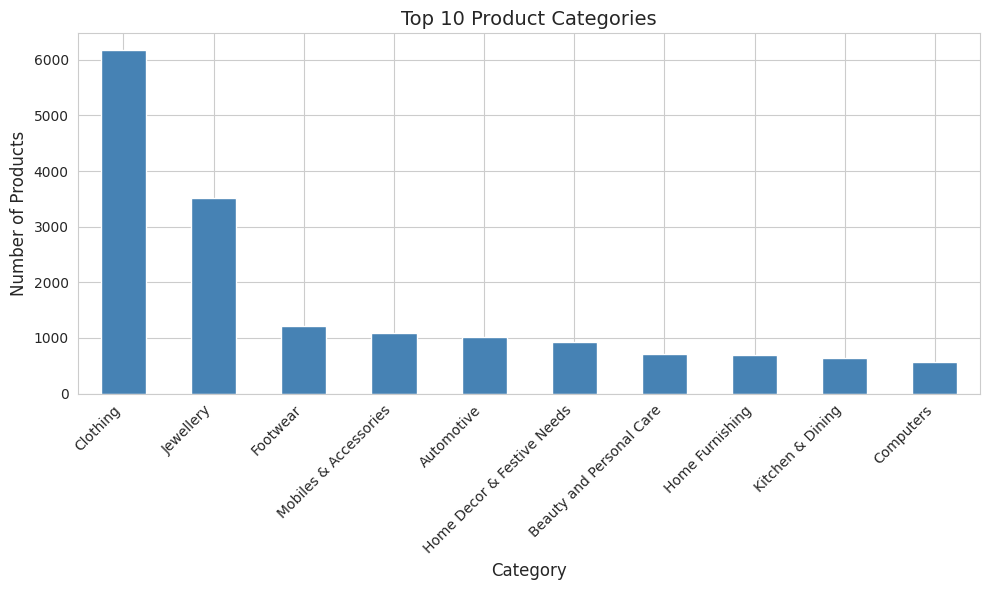

In [18]:

# Get the top 10 categories by product count
top_categories = df['main_category'].value_counts().head(10)

# Create a bar chart
plt.figure(figsize=(10, 6))
top_categories.plot(kind='bar', color='steelblue')

# Add title and labels
plt.title('Top 10 Product Categories', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()

# **Step 18: Visualize Price Distribution**

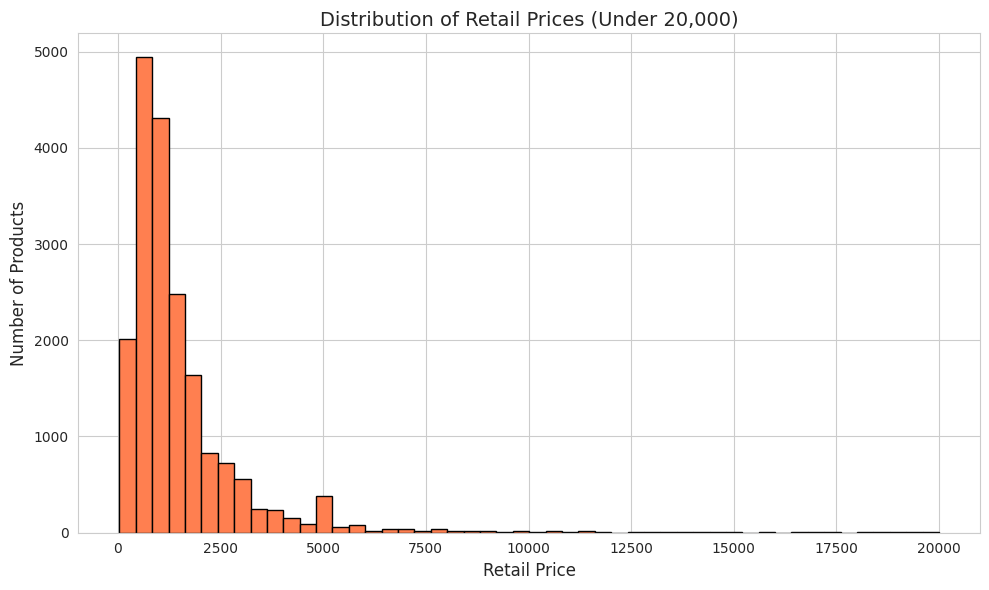

In [19]:


# Filter data to only include prices below 20000 before plotting
filtered_prices = df[df['retail_price'] < 20000]['retail_price']

# Create a histogram using the filtered data
plt.figure(figsize=(10, 6))
plt.hist(filtered_prices, bins=50, color='coral', edgecolor='black')

# Add title and labels
plt.title('Distribution of Retail Prices (Under 20,000)', fontsize=14)
plt.xlabel('Retail Price', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

# **Step 19: Compare Retail Price vs Discounted Price**

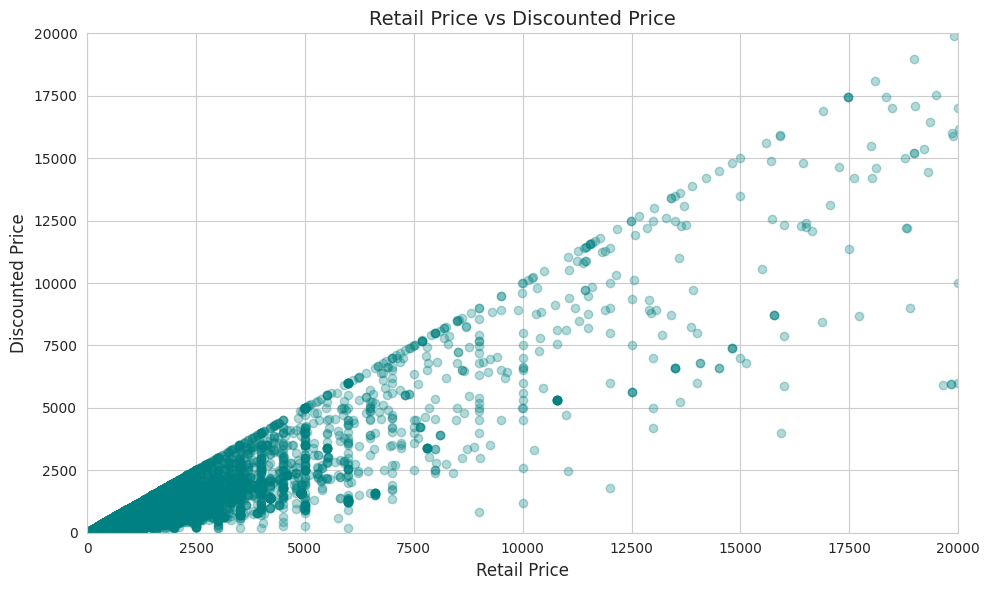

In [21]:

# Create a scatter plot to compare retail price and discounted price
plt.figure(figsize=(10, 6))
plt.scatter(df['retail_price'], df['discounted_price'], alpha=0.3, color='teal')

# Add title and labels
plt.title('Retail Price vs Discounted Price', fontsize=14)
plt.xlabel('Retail Price', fontsize=12)
plt.ylabel('Discounted Price', fontsize=12)

# Limit both axes to focus on the main data range
plt.xlim(0, 20000)
plt.ylim(0, 20000)

# Display the plot
plt.tight_layout()
plt.show()

# **Step 20: Calculate and Visualize Discount Percentage**

In [24]:
# Calculate discount percentage for each product
df['discount_percentage'] = ((df['retail_price'] - df['discounted_price']) / df['retail_price']) * 100

# Display basic statistics of discount percentage
print(df['discount_percentage'].describe())

count    19905.000000
mean        40.523837
std         23.546739
min          0.000000
25%         21.074816
50%         45.000000
75%         59.973316
max         96.533333
Name: discount_percentage, dtype: float64


# **Step 21: Visualize Discount Percentage Distribution**

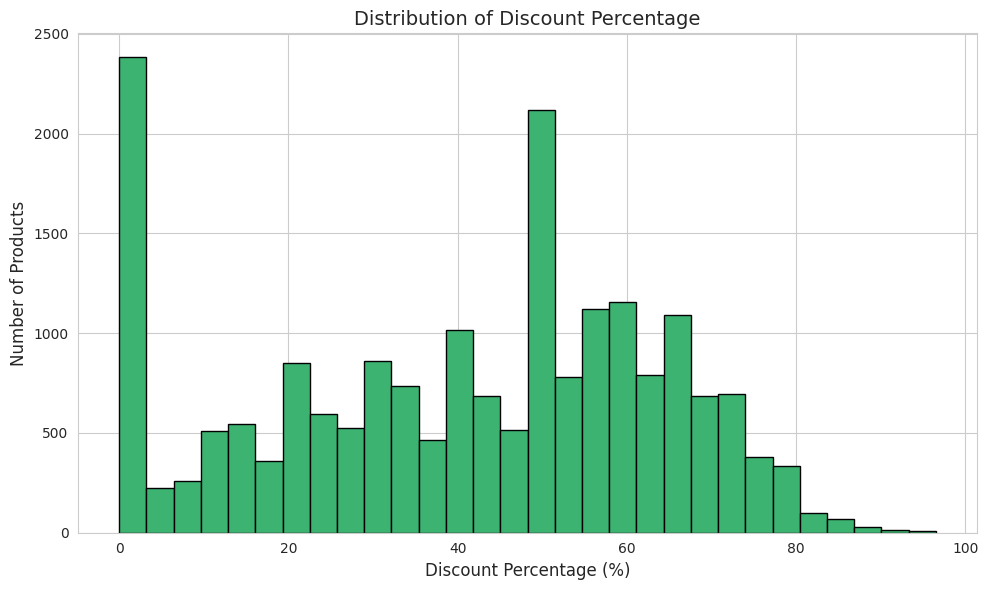

In [23]:
# Create a histogram of discount percentages
plt.figure(figsize=(10, 6))
plt.hist(df['discount_percentage'], bins=30, color='mediumseagreen', edgecolor='black')

# Add title and labels
plt.title('Distribution of Discount Percentage', fontsize=14)
plt.xlabel('Discount Percentage (%)', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()